# Pré-processamento

Previsão da linha de atuação parlamentar (governista × oposição) a partir do perfil eleitoral (TSE).

Este notebook cobre **apenas o pré-processamento**, partindo da base já coletada e integrada `dataset.csv`. A estrutura segue a da disciplina:

1. **Limpeza de dados** — tipo/escala dos atributos, seleção de atributos, valores ausentes, instâncias duplicadas, outliers
2. **Exploração (estatística descritiva)** — frequência, localidade, dispersão, distribuição, correlação
3. **Transformação** — conversão simbólico→numérico (One-Hot) e normalização

A saída é a matriz de atributos `X` (pronta para os modelos) e o vetor-alvo `y`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
df = pd.read_csv('dataset.csv')
print('instâncias, atributos:', df.shape)

instâncias, atributos: (590, 16)


# 1. Limpeza de dados

## 1.1 Conheça seus dados

Antes de qualquer transformação, uma olhada direta na base (*"uma simples olhada em uma planilha pode fazer toda a diferença"*).

In [2]:
df.head()

,idDeputado,nome,cpf,partido,federacao,uf,regiao,idade,genero,grau_instrucao,cor_raca,ocupacao,patrimonio_total,pct_alinhamento_gov,n_votacoes,rotulo
0,62881,Danilo Forte,12133728368,UNIÃO,#NULO,CE,NE,64,MASCULINO,SUPERIOR COMPLETO,BRANCA,ADVOGADO,3231234.32,0.7630,270,governista
1,66385,Julio Arcoverde,77309766768,PP,#NULO,PI,NE,56,MASCULINO,SUPERIOR COMPLETO,PARDA,DEPUTADO,2346554.16,0.8344,308,governista
2,66828,Fausto Pinato,28022995819,PP,#NULO,SP,SE,45,MASCULINO,SUPERIOR COMPLETO,BRANCA,ADVOGADO,712867.36,0.8556,284,governista
3,68720,Fábio Henrique,41330200578,UNIÃO,#NULO,SE,NE,50,MASCULINO,SUPERIOR COMPLETO,PARDA,OUTROS,760000.00,0.8571,49,governista
4,69871,Bacelar,10626409500,PV,PT/PC do B/PV,BA,NE,65,MASCULINO,SUPERIOR COMPLETO,BRANCA,DEPUTADO,462181.22,1.0000,340,governista


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590 entries, 0 to 589
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   idDeputado           590 non-null    int64  
 1   nome                 590 non-null    str    
 2   cpf                  590 non-null    int64  
 3   partido              590 non-null    str    
 4   federacao            590 non-null    str    
 5   uf                   590 non-null    str    
 6   regiao               590 non-null    str    
 7   idade                590 non-null    int64  
 8   genero               590 non-null    str    
 9   grau_instrucao       590 non-null    str    
 10  cor_raca             590 non-null    str    
 11  ocupacao             590 non-null    str    
 12  patrimonio_total     590 non-null    float64
 13  pct_alinhamento_gov  590 non-null    float64
 14  n_votacoes           590 non-null    int64  
 15  rotulo               590 non-null    str    
dtypes

## 1.2 Tipo e escala dos atributos

Cada coluna é classificada quanto ao **tipo** (numérico / nominal) e à **escala** (nominal, ordinal, racional), o que determina o tratamento posterior.

| Atributo | Tipo | Escala | Papel |
|---|---|---|---|
| `idDeputado`, `nome`, `cpf` | — | — | identificador (descartar) |
| `partido`, `federacao`, `uf`, `genero`, `cor_raca`, `ocupacao` | nominal | nominal | feature categórica |
| `regiao` | nominal | nominal | feature categórica |
| `grau_instrucao` | nominal | ordinal | feature categórica (tratada como nominal) |
| `idade` | numérico | racional | feature numérica |
| `patrimonio_total` | numérico | racional | feature numérica |
| `pct_alinhamento_gov`, `n_votacoes` | numérico | racional | pós-eleição → vazamento (descartar) |
| `rotulo` | nominal | nominal | **alvo** |

## 1.3 Seleção adequada de atributos

Removem-se atributos que não devem entrar no modelo:

- **Irrelevantes para o que se deseja aprender** (como *"nome do paciente"* nos slides): `idDeputado`, `nome`, `cpf` — identificadores sem poder preditivo.
- **Vazamento de dados** (*data leakage*): `pct_alinhamento_gov` e `n_votacoes` derivam do comportamento de voto **posterior** à eleição — a mesma informação que origina o rótulo. Usá-las como feature seria "trapacear".

Ficam apenas as features do TSE, todas anteriores à eleição.

In [4]:
CATEGORICAS = ['partido', 'federacao', 'uf', 'regiao', 'genero',
               'grau_instrucao', 'cor_raca', 'ocupacao']
NUMERICAS = ['idade', 'patrimonio_total']

descartar = ['idDeputado', 'nome', 'cpf', 'pct_alinhamento_gov', 'n_votacoes']
print('atributos descartados:', descartar)

X = df[CATEGORICAS + NUMERICAS].copy()
y = df['rotulo'].copy()
print('features mantidas:', X.shape[1], '|', list(X.columns))

atributos descartados: ['idDeputado', 'nome', 'cpf', 'pct_alinhamento_gov', 'n_votacoes']
features mantidas: 10 | ['partido', 'federacao', 'uf', 'regiao', 'genero', 'grau_instrucao', 'cor_raca', 'ocupacao', 'idade', 'patrimonio_total']


## 1.4 Valores ausentes

Tratamento possível (slides): **descarte** (evita introdução de erros, mas pode reduzir a amostra) ou **estimação** (nominais → moda; contínuos → média). A decisão depende de **verificar** se há ausência. Auditoria em três frentes.

In [5]:
# (a) valores nulos (NaN / vazios)
nulos = df.isnull().sum()
print('total de células nulas:', int(nulos.sum()))
print('linhas com algum nulo :', int(df.isnull().any(axis=1).sum()))

total de células nulas: 0
linhas com algum nulo : 0


In [6]:
# (b) marcadores de ausência usados pelo TSE (#NULO, #NE, -1) — não viram NaN automaticamente
marcadores = ['#NULO', '#NE', '#NI', 'NÃO INFORMADO', '-1', '']
achados = {c: int(df[c].isin(marcadores).sum())
           for c in df.select_dtypes(include='object').columns
           if df[c].isin(marcadores).sum() > 0}
print('marcadores de ausência encontrados:', achados if achados else 'NENHUM')

marcadores de ausência encontrados: {'federacao': 472, 'cor_raca': 1}


/tmp/ipykernel_548661/2381909291.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for c in df.select_dtypes(include='object').columns


In [7]:
# (c) consistência das variáveis numéricas
print('idade — min:', df['idade'].min(), '| max:', df['idade'].max(),
      '| fora da faixa (<=0 ou >100):', int(((df['idade'] <= 0) | (df['idade'] > 100)).sum()))
print('patrimonio_total negativo:', int((df['patrimonio_total'] < 0).sum()))
print('patrimonio_total == 0    :', int((df['patrimonio_total'] == 0).sum()),
      '(sem bens declarados — valor real, não ausente)')

idade — min: 21 | max: 88 | fora da faixa (<=0 ou >100): 0
patrimonio_total negativo: 0
patrimonio_total == 0    : 22 (sem bens declarados — valor real, não ausente)


**Decisão — não descartar nenhuma linha.** As verificações não encontraram dados ausentes: a junção por CPF é *inner* (não gera linha órfã com campos vazios, e o casamento foi 590/590), o único marcador do TSE (`#NULO` em `federacao`) já foi convertido na categoria `SEM` durante a coleta (ausência **informativa**, não faltante), e `patrimonio_total = 0` é valor verdadeiro. Como salvaguarda, o pipeline (§3) ainda inclui imputação (moda para nominais, mediana para numéricas), de modo que qualquer ausência residual seria estimada — sem perder instâncias.

In [8]:
# confirmação: o descarte não remove nada
antes = len(df)
_ = df.dropna()
print('linhas que seriam removidas por descarte de ausentes:', antes - len(_))

linhas que seriam removidas por descarte de ausentes: 0


## 1.5 Instâncias duplicadas

Duplicatas podem ser **ilegítimas** (mesmo deputado repetido) ou **legítimas** (dois deputados com o mesmo perfil). Verifica-se pela chave única (`cpf`).

In [9]:
print('linhas totais        :', len(df))
print('CPFs únicos          :', df['cpf'].nunique())
print('linhas inteiras dup. :', int(df.duplicated().sum()))
print('CPFs duplicados      :', int(df['cpf'].duplicated().sum()), '(0 = nenhuma duplicata ilegítima)')

linhas totais        : 590
CPFs únicos          : 590
linhas inteiras dup. : 0
CPFs duplicados      : 0 (0 = nenhuma duplicata ilegítima)


## 1.6 Outliers

Instâncias "anômalas", com valor muito diferente da maioria. `patrimonio_total` é o caso mais sensível (varia de 0 a centenas de milhões).

/tmp/ipykernel_548661/4195381734.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[0].boxplot(df['patrimonio_total'] / 1e6, vert=False)
/tmp/ipykernel_548661/4195381734.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df['idade'], vert=False)


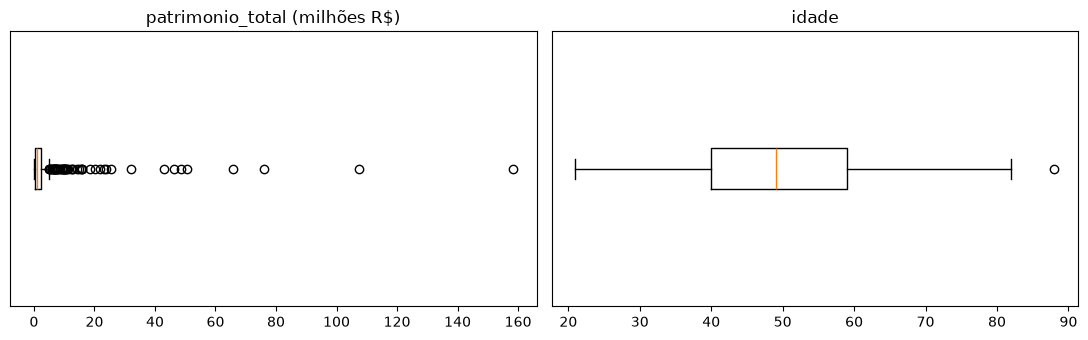

patrimônio acima do limite do boxplot (outliers): 56


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].boxplot(df['patrimonio_total'] / 1e6, vert=False)
ax[0].set_title('patrimonio_total (milhões R$)'); ax[0].set_yticks([])
ax[1].boxplot(df['idade'], vert=False)
ax[1].set_title('idade'); ax[1].set_yticks([])
plt.tight_layout(); plt.show()

q1, q3 = df['patrimonio_total'].quantile([0.25, 0.75])
lim_sup = q3 + 1.5 * (q3 - q1)
print('patrimônio acima do limite do boxplot (outliers):',
      int((df['patrimonio_total'] > lim_sup).sum()))

**Decisão — manter os outliers de patrimônio.** São valores **reais** (deputados de patrimônio muito alto existem), não erros de medição. Remover enviesaria a amostra. O efeito de escala é tratado na normalização (§3.2), e os modelos baseados em árvore são robustos a outliers.

# 2. Exploração (estatística descritiva)

Análise para conhecer o comportamento dos dados antes de modelar.

## 2.1 Univariada — Frequência

Frequência absoluta e relativa das variáveis nominais e do alvo.

In [11]:
# alvo: frequência absoluta e relativa
freq = df['rotulo'].value_counts()
rel = df['rotulo'].value_counts(normalize=True).round(3)
print('rótulo — frequência absoluta:\n', freq.to_string(), sep='')
print('\nrótulo — frequência relativa:\n', rel.to_string(), sep='')

rótulo — frequência absoluta:
rotulo
governista    435
oposicao      155

rótulo — frequência relativa:
rotulo
governista    0.737
oposicao      0.263


In [12]:
# partido: 10 mais frequentes
df['partido'].value_counts().head(10)

partido
PL              112
PT               72
UNIÃO            67
PSD              57
PP               56
MDB              48
REPUBLICANOS     47
PDT              21
PODE             15
PSB              14
Name: count, dtype: int64

## 2.2 Univariada — Localidade e Dispersão

Medidas de **localidade** (mínimo, máximo, média, mediana, moda) e de **dispersão** (amplitude, desvio padrão, variância) das variáveis numéricas.

In [13]:
resumo = pd.DataFrame({
    'minimo':   df[NUMERICAS].min(),
    'maximo':   df[NUMERICAS].max(),
    'media':    df[NUMERICAS].mean(),
    'mediana':  df[NUMERICAS].median(),
    'amplitude': df[NUMERICAS].max() - df[NUMERICAS].min(),
    'desvio_padrao': df[NUMERICAS].std(),
    'variancia': df[NUMERICAS].var(),
}).round(2)
resumo

,minimo,maximo,media,mediana,amplitude,desvio_padrao,variancia
idade,21.0,8.800000e+01,49.91,49.0,6.700000e+01,12.23,1.496500e+02
patrimonio_total,0.0,1.581845e+08,2990167.15,945945.1,1.581845e+08,10061051.07,1.012247e+14


## 2.3 Univariada — Distribuição

Histograma e **assimetria (skewness)** das numéricas. Espera-se forte assimetria à direita em `patrimonio_total` (poucos com patrimônio muito alto).

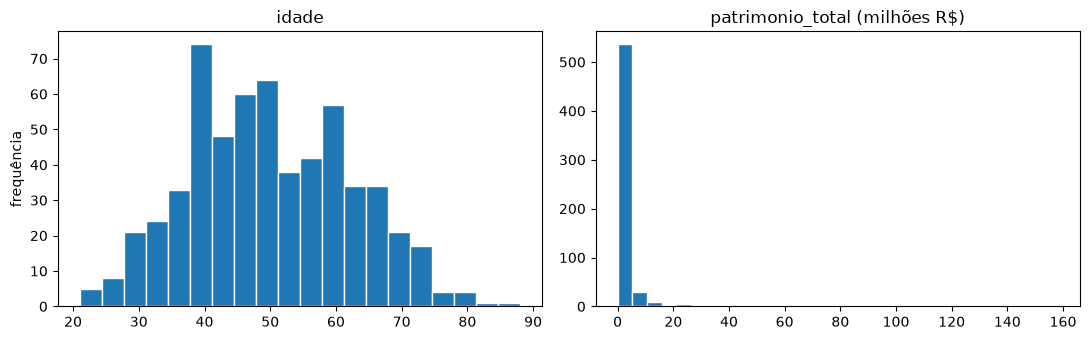

assimetria (skewness):
  idade           : 0.18
  patrimonio_total: 9.953 (>0 = cauda à direita)


In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df['idade'], bins=20, edgecolor='white')
ax[0].set_title('idade'); ax[0].set_ylabel('frequência')
ax[1].hist(df['patrimonio_total'] / 1e6, bins=30, edgecolor='white')
ax[1].set_title('patrimonio_total (milhões R$)')
plt.tight_layout(); plt.show()

print('assimetria (skewness):')
print('  idade           :', round(df['idade'].skew(), 3))
print('  patrimonio_total:', round(df['patrimonio_total'].skew(), 3), '(>0 = cauda à direita)')

## 2.4 Multivariada — Correlação

Correlação entre as variáveis numéricas (valores próximos de 0 indicam ausência de relação linear).

In [15]:
df[NUMERICAS].corr().round(3)

,idade,patrimonio_total
idade,1.000,0.143
patrimonio_total,0.143,1.000


# 3. Transformação

Várias técnicas de AM exigem atributos numéricos. Converte-se o simbólico em numérico e ajusta-se a escala.

## 3.1 Conversão simbólico → numérico

### Rótulo (nominal com 2 valores → dígito binário)
`governista` → 1, `oposicao` → 0.

In [16]:
y = (y == 'governista').astype(int)
y.value_counts()

rotulo
1    435
0    155
Name: count, dtype: int64

### Categóricas nominais com mais de 2 valores → "sequência de bits" (One-Hot Encoding)

Cada valor possível vira uma coluna com 1 bit em 1 e os demais em 0 (Abordagem 1 dos slides). `handle_unknown='ignore'` evita erro quando surge uma categoria não vista na validação. Abaixo, quantas colunas cada atributo gera.

In [17]:
X[CATEGORICAS].nunique()

partido           23
federacao          4
uf                27
regiao             5
genero             2
grau_instrucao     6
cor_raca           6
ocupacao          50
dtype: int64

## 3.2 Normalização (variância e média)

`idade` e `patrimonio_total` estão em escalas muito diferentes — sem ajuste, `patrimonio_total` (até ~1,6×10⁸) dominaria qualquer atributo. Aplica-se a **normalização por variância e média** (`StandardScaler`):

$$\hat{x} = \frac{x - \mu}{\sigma}$$

resultando em média 0 e desvio padrão 1.

## 3.3 Pipeline de transformação

One-Hot (categóricas) + normalização (numéricas) reunidos em um `ColumnTransformer`. Encapsulado em `Pipeline`, o `fit` ocorre **apenas no treino** de cada *fold* da validação — evitando vazamento do conjunto de teste.

In [18]:
preprocessador = ColumnTransformer([
    ('cat', Pipeline([
        ('imput', SimpleImputer(strategy='most_frequent')),   # estima nominais pela moda
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), CATEGORICAS),
    ('num', Pipeline([
        ('imput', SimpleImputer(strategy='median')),          # estima numéricas pela mediana
        ('escala', StandardScaler()),                          # normalização variância e média
    ]), NUMERICAS),
])

X_proc = preprocessador.fit_transform(X)
print('matriz de atributos processada:', X_proc.shape)

matriz de atributos processada: (590, 125)


In [19]:
nomes = preprocessador.get_feature_names_out()
print('colunas após One-Hot + normalização:', len(nomes))
print('exemplos:', list(nomes[:4]), '...', list(nomes[-2:]))

colunas após One-Hot + normalização: 125
exemplos: ['cat__partido_AVANTE', 'cat__partido_CIDADANIA', 'cat__partido_MDB', 'cat__partido_NOVO'] ... ['num__idade', 'num__patrimonio_total']


# Resultado

- `X_proc` — matriz de atributos pronta (One-Hot nas categóricas + numéricas normalizadas), sem identificadores e sem vazamento.
- `y` — alvo binário (1 = governista, 0 = oposição).
- `preprocessador` — objeto reutilizável, acoplado a cada modelo na etapa de treino/validação (próximo notebook), garantindo ajuste apenas sobre os dados de treino.

In [20]:
print('X_proc:', X_proc.shape)
print('y     :', y.shape, '| governistas:', int(y.sum()), '| oposição:', int((y == 0).sum()))

X_proc: (590, 125)
y     : (590,) | governistas: 435 | oposição: 155
